## Настройка среды

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## Загрузка датасета

In [168]:
df = pd.read_csv('/Users/sergei/Downloads/_data.csv')
df.head(3)

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,Телефоны,Описание,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,0,271271157,4,Квартира,м. Смоленская (9 мин пешком),"Москва, улица Новый Арбат, 27",200.0/20.0,"5/16, Монолитный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79166369231,Без комиссии для нанимателя! Бонус коллегам 12...,Дизайнерский,NaN,NaN,NaN,NaN,"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Душ...","Новый Арбат, 2010",NaN,3.00,"Пасс (4), Груз (1)",Да,https://www.cian.ru/rent/flat/271271157
1,1,271634126,4,Квартира,м. Смоленская (8 мин пешком),"Москва, улица Новый Арбат, 27",198.0/95.0/18.0,"5/16, Монолитно-кирпичный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79850608590,Лот 93107. Елена Анисимова.\n\nБонус агенту 50...,Дизайнерский,25 25 20 25,NaN,На улицу и двор,"Совмещенный (2), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.50,"Пасс (1), Груз (1)",Нет,https://www.cian.ru/rent/flat/271634126
2,2,271173086,"4, Оба варианта",Квартира,м. Смоленская (7 мин пешком),"Москва, улица Новый Арбат, 27",200.0/116.0/4.0,5/16,подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...","+79672086536, +79099269384","ID 36380: Шикарная 4-х км. квартира в ЖК ""Нов...",Евроремонт,NaN,NaN,На улицу и двор,Совмещенный (3),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.20,Пасс (1),NaN,https://www.cian.ru/rent/flat/271173086


## Шаг 1. Общая информация о датасете

In [169]:
def analyze_missing_data(df, threshold=0):
    missing_data = df.isna().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Количество пропусков': missing_data,
        'Процент пропусков': missing_percent})
    
    return missing_df[missing_df['Количество пропусков'] > threshold].sort_values('Количество пропусков', ascending=False)

missing_info = analyze_missing_data(df)
print("Пропущенные данные:")
print(missing_info)

Пропущенные данные:
                          Количество пропусков  Процент пропусков
Серия дома                               21205              90.74
Название ЖК                              17520              74.97
Парковка                                 13417              57.42
Высота потолков, м                       12162              52.05
Мусоропровод                             10522              45.03
Площадь комнат, м2                        8910              38.13
Балкон                                    7978              34.14
Окна                                      6613              28.30
Можно с детьми/животными                  6096              26.09
Лифт                                      5500              23.54
Ремонт                                    2755              11.79
Санузел                                   2672              11.43
Метро                                     1315               5.63
Количество комнат                         1041          

## Шаг 2. Переводим цену, указанную в валюте, в рубли

In [170]:
# Курс закреплён на 20.11.2025 12:00
USD_TO_RUB = 80.15
EUR_TO_RUB = 92.44

def parse_price(x):
    s = str(x)
    nums = re.findall(r'\d+\.?\d*', s)
    if not nums: return np.nan
    rate = USD_TO_RUB if any(c in s for c in '$USD') else EUR_TO_RUB if any(c in s for c in '€EUR') else 1
    return float(nums[0]) * rate

df['monthly_rent_rub'] = df['Цена'].apply(parse_price).round()

## Шаг 3. Распределение объявлений по ценовым сегментам

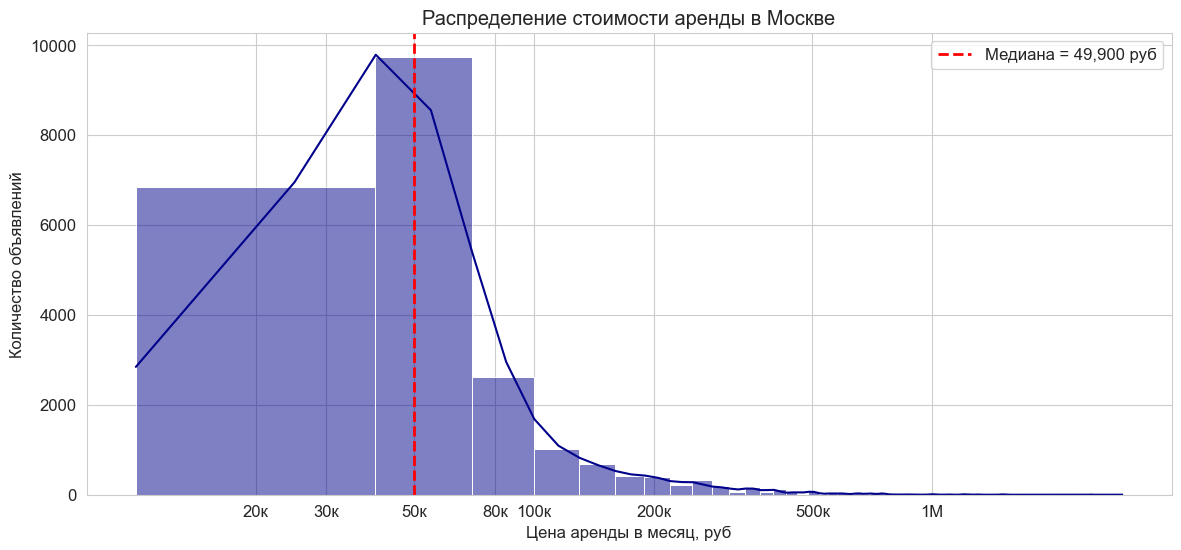

In [180]:
df['monthly_rent_rub'] = df['Цена'].apply(parse_price).round()

plt.figure(figsize=(14,6))
sns.histplot(df['monthly_rent_rub'].dropna(), bins=100, kde=True, color='darkblue')
plt.xscale('log')
plt.xticks([20_000, 30_000, 50_000, 80_000, 100_000, 200_000, 500_000, 1_000_000],
           ['20к', '30к', '50к', '80к', '100к', '200к', '500к', '1М'])
plt.title('Распределение стоимости аренды в Москве')
plt.xlabel('Цена аренды в месяц, руб')
plt.ylabel('Количество объявлений')
plt.axvline(df['monthly_rent_rub'].median(), color='red', linestyle='--', linewidth=2, 
            label=f'Медиана = {df["monthly_rent_rub"].median():,.0f} руб')
plt.legend()
plt.show()

***Распределение цены аренды (Москва, 23 368 объявлений)**

- Логарифмическая шкала — чтобы уместить весь ценовой диапазон наглядно: от 13 тыс. до 11 млн.
- Пик — около 40–60 тысяч руб. (самые частые предложения).
- Красная линия — **медиана = 49 900 руб.**
  → половина квартир в Москве сдаётся дешевле 50 тысяч, половина — дороже.
- Длинный «хвост» вправо — элитное жильё (от 200 тыс. и выше), их намного меньше.

**Вывод для бизнеса:**  
80–90 % рынка — это квартиры до 100 тыс. руб. 

## Шаг 4. Распределение объявлений по ценовым сегментам

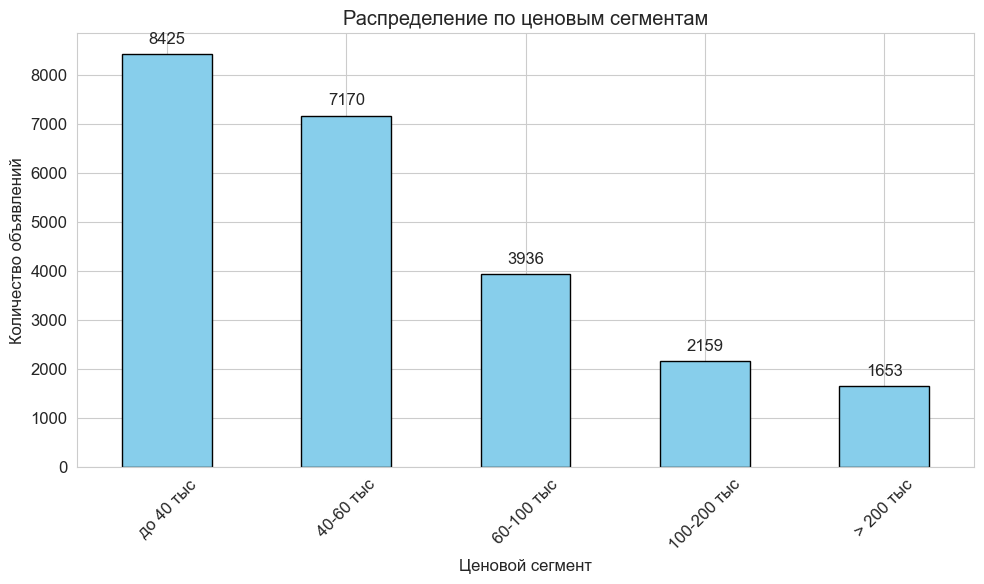

In [186]:
bins = [0, 40000, 60000, 100000, 200000, df['monthly_rent_rub'].max()]
labels = ['до 40 тыс', '40-60 тыс', '60-100 тыс', '100-200 тыс', '> 200 тыс']

df['price_group'] = pd.cut(df['monthly_rent_rub'], bins=bins, labels=labels)
counts = df['price_group'].value_counts().sort_index()

plt.figure(figsize=(10,6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение по ценовым сегментам')
plt.xlabel('Ценовой сегмент')
plt.ylabel('Количество объявлений')
plt.xticks(rotation=45)

for i, v in enumerate(counts):
    plt.text(i, v + 150, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Шаг 5. Топ-10 станций метро по количеству объявлений

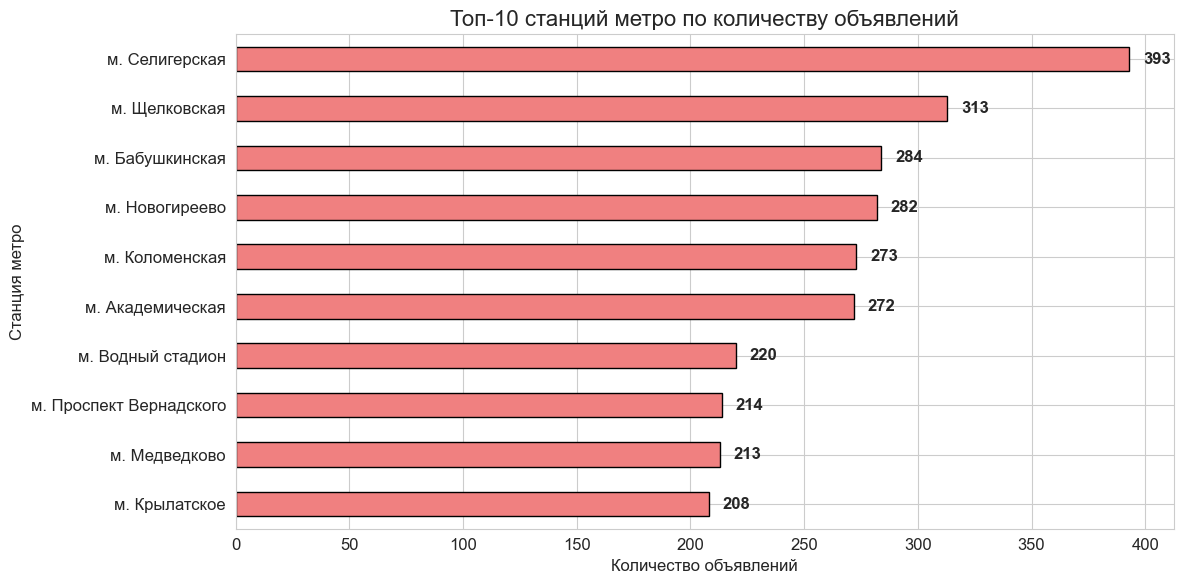

In [185]:
df['metro_station'] = df['Метро'].astype(str).str.split('(').str[0].str.strip()

# Убираем 'nan', 'None', пустые строки и т.д.
valid_metro = df[df['metro_station'].notna() & 
                 (df['metro_station'] != 'nan') & 
                 (df['metro_station'] != '')]

top10_metro = valid_metro['metro_station'].value_counts().head(10)

plt.figure(figsize=(12,6))
top10_metro.sort_values().plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title('Топ-10 станций метро по количеству объявлений', fontsize=16)
plt.xlabel('Количество объявлений')
plt.ylabel('Станция метро')

# Подписываем цифры справа
for i, v in enumerate(top10_metro.sort_values()):
    plt.text(v + 6, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Шаг 6. Зависимость цены от площади (+ обзор этого соотношения для элитного рынка)

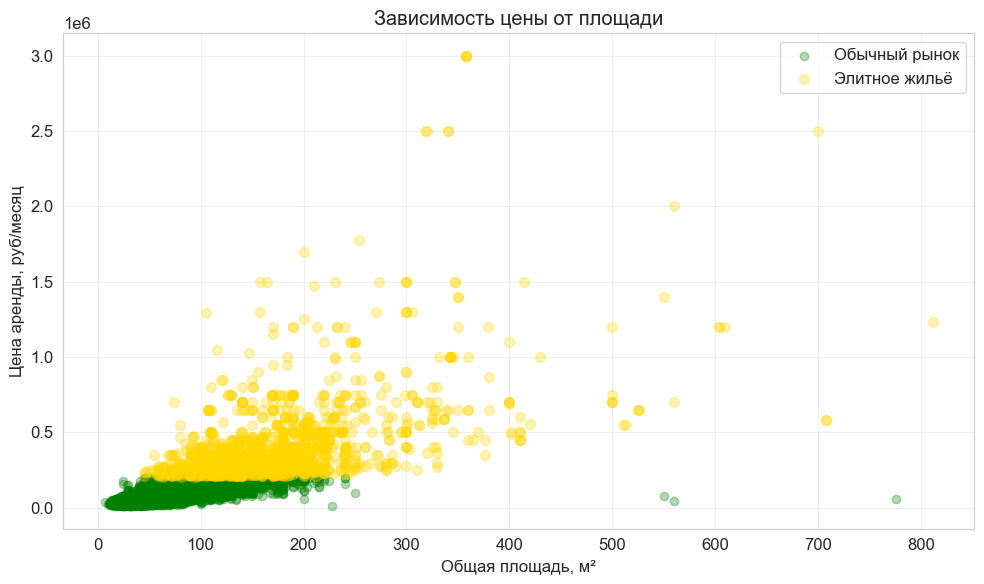

In [187]:
df['total_area'] = df['Площадь, м2'].str.split('/').str[0].str.replace(',', '.').astype(float)
df_normal = df[df['monthly_rent_rub'] <= 200000]
df_elite = df[df['monthly_rent_rub'] > 200000]

plt.figure(figsize=(10,6))
plt.scatter(df_normal['total_area'], df_normal['monthly_rent_rub'], alpha=0.3, color='green', label='Обычный рынок')
plt.scatter(df_elite['total_area'], df_elite['monthly_rent_rub'], alpha=0.3, color='gold', s=50, label='Элитное жильё')
plt.title('Зависимость цены от площади')
plt.xlabel('Общая площадь, м²')
plt.ylabel('Цена аренды, руб/месяц')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Шаг 7. Основной рынок по количеству комнат и ремонту 

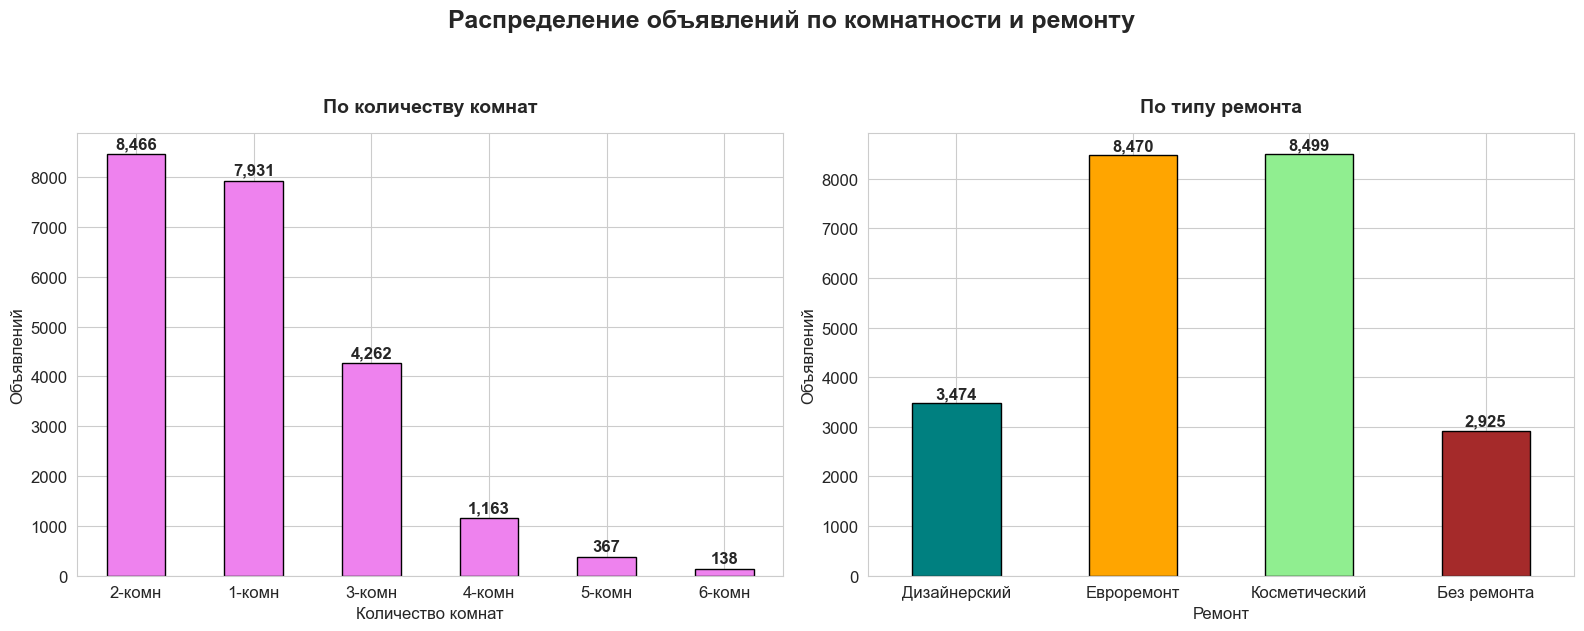

In [198]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Комнаты ---
def rooms_cat(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if any(w in s for w in ['студия', 'своб', '0']): return 'Студия'
    n = re.search(r'\d+', s)
    return f"{n.group()}-комн" if n else np.nan

rooms = df['Количество комнат'].apply(rooms_cat).value_counts().sort_values(ascending=False)
rooms.plot(kind='bar', ax=ax1, color='violet', edgecolor='black')
ax1.set_title('По количеству комнат', fontsize=14, weight='bold', pad=15)
ax1.set_ylabel('Объявлений')
for i, v in enumerate(rooms):
    ax1.text(i, v + 120, f'{v:,}', ha='center', fontweight='bold')

# --- Ремонт ---
repair_order = ['Дизайнерский', 'Евроремонт', 'Косметический', 'Без ремонта']
repair_colors = ['teal', 'orange', 'lightgreen', 'brown']
repair = df['Ремонт'].fillna('Без ремонта').value_counts().loc[repair_order]

repair.plot(kind='bar', ax=ax2, color=repair_colors, edgecolor='black')
ax2.set_title('По типу ремонта', fontsize=14, weight='bold', pad=15)
ax2.set_ylabel('Объявлений')
for i, v in enumerate(repair):
    ax2.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

for ax in (ax1, ax2):
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Распределение объявлений по комнатности и ремонту', 
             fontsize=18, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Шаг 8. Влияние этажа на цену

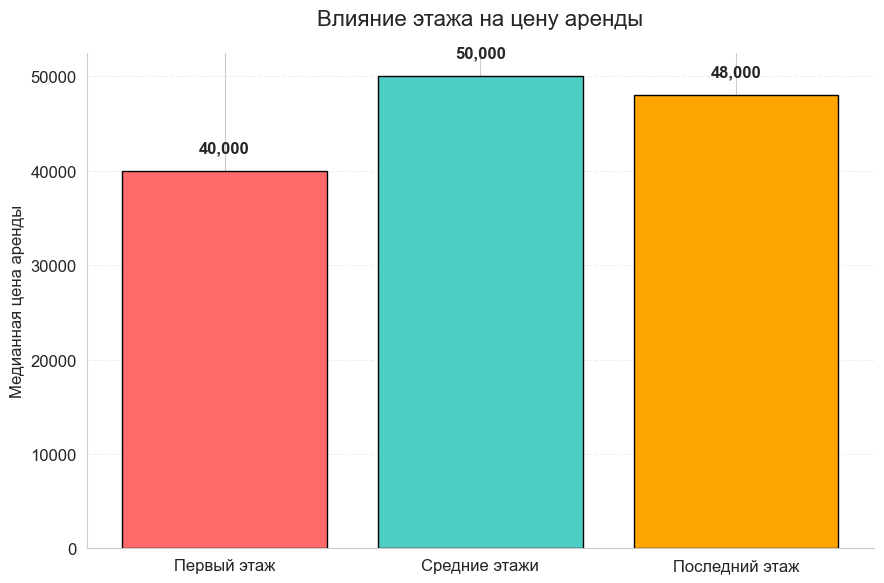

In [191]:
df['floor'], df['total_floors'] = zip(*df['Дом'].astype(str).str.findall(r'\d+').apply(
    lambda x: (int(x[0]) if len(x)>0 else None, int(x[1]) if len(x)>1 else None)))

df['is_first'] = df['floor'] == 1
df['is_last']  = df['floor'] == df['total_floors']

prices = [df[df['is_first']]['monthly_rent_rub'].median(),
    df[~df['is_first'] & ~df['is_last']]['monthly_rent_rub'].median(),
    df[df['is_last']]['monthly_rent_rub'].median()]

plt.figure(figsize=(9, 6))
plt.bar(['Первый этаж', 'Средние этажи', 'Последний этаж'], prices,
        color=['#FF6B6B', '#4ECDC4', '#FFA502'], edgecolor='black')

for i, v in enumerate(prices):
    plt.text(i, v + 2000, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=12)

plt.title('Влияние этажа на цену аренды', fontsize=16, pad=20)
plt.ylabel('Медианная цена аренды')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Шаг 9. Влияние удалённости квартиры от метро на цену

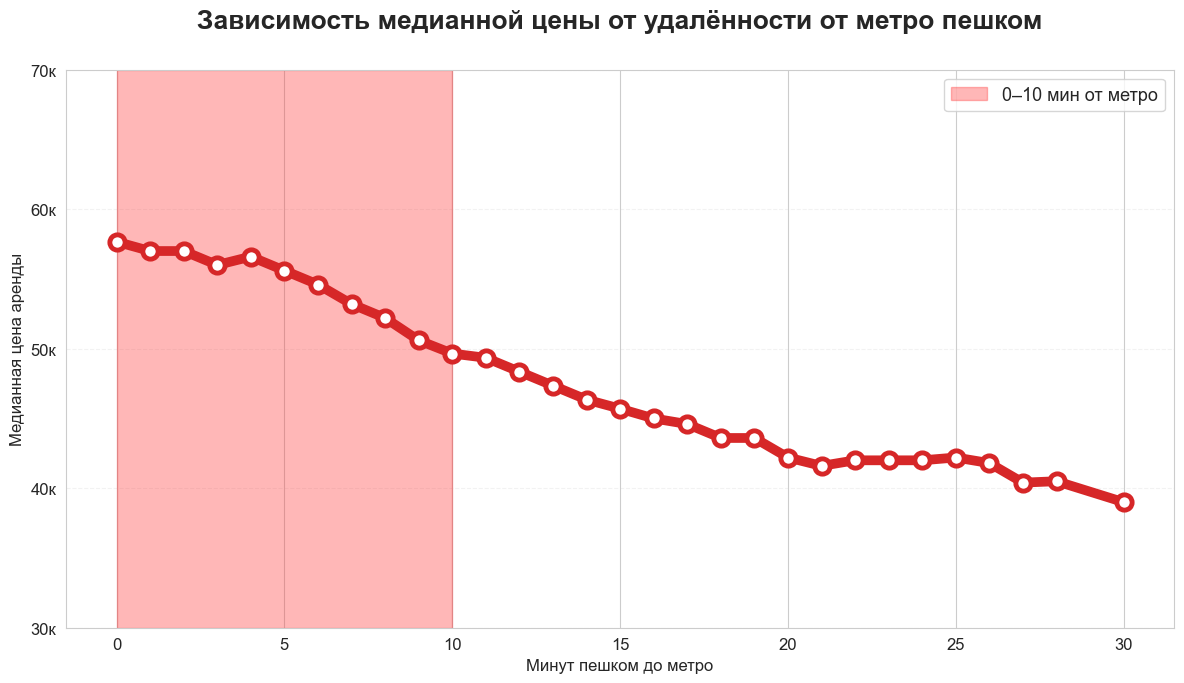

In [140]:
df['min_walk'] = df['Метро'].str.extract(r'(\d+)\s*мин.*?пешком', flags=re.I).astype(float)

agg = (df[df['min_walk']<=30]
       .groupby('min_walk')['monthly_rent_rub'].median()
       .loc[lambda s: df['min_walk'].value_counts()[s.index]>30]
       .rolling(5, center=True, min_periods=1).mean())

plt.figure(figsize=(12,7))
plt.plot(agg.index, agg, 'o-', color='#d62728', lw=7, ms=11, mfc='white', mew=3.5)
plt.axvspan(0,10, color='#ff3333', alpha=0.35, label='0–10 мин от метро')
plt.ylim(30000,70000); plt.yticks([30000,40000,50000,60000,70000], ['30к','40к','50к','60к','70к'])
plt.tick_params(right=False, labelright=False)
plt.title('Зависимость медианной цены от удалённости от метро пешком', fontsize=19, weight='bold', pad=30)
plt.xlabel('Минут пешком до метро'); plt.ylabel('Медианная цена аренды')
plt.grid(alpha=0.25, axis='y', ls='--'); plt.legend(fontsize=13); plt.tight_layout(); plt.show()

## Шаг 10. Влияние типа дома (монолит/панель/кирпич/сталинка) на цену 

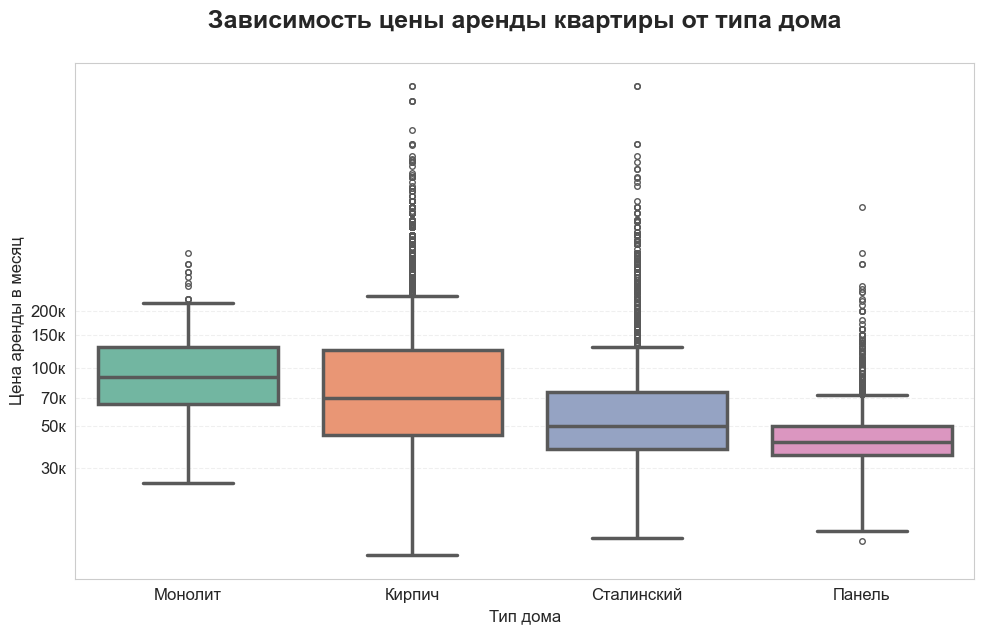

In [151]:
df['house_type'] = df['Дом'].str.extract(r'(Монолит|Кирпич|Панель|Сталин|Блок)', expand=False)

plt.figure(figsize=(10,6.5))
sns.boxplot(data=df[df['house_type'].notna()],
            x='house_type', y='monthly_rent_rub',
            order=df.groupby('house_type')['monthly_rent_rub'].median().sort_values(ascending=False).index,
            palette='Set2', linewidth=2.5, fliersize=4)

plt.yscale('log')
plt.yticks([30000,50000,70000,100000,150000,200000], 
           ['30к','50к','70к','100к','150к','200к'])

plt.title('Зависимость цены аренды квартиры от типа дома', 
          fontsize=18, weight='bold', pad=25)
plt.xlabel('Тип дома'); plt.ylabel('Цена аренды в месяц')
plt.grid(alpha=0.3, axis='y', ls='--')

plt.gca().set_xticklabels(['Монолит', 'Кирпич', 'Сталинский', 'Панель', 'Блочный'])

plt.tight_layout(); plt.show()

## Шаг 11. Влияние нахождение квартиры в ЦАО на цену аренда

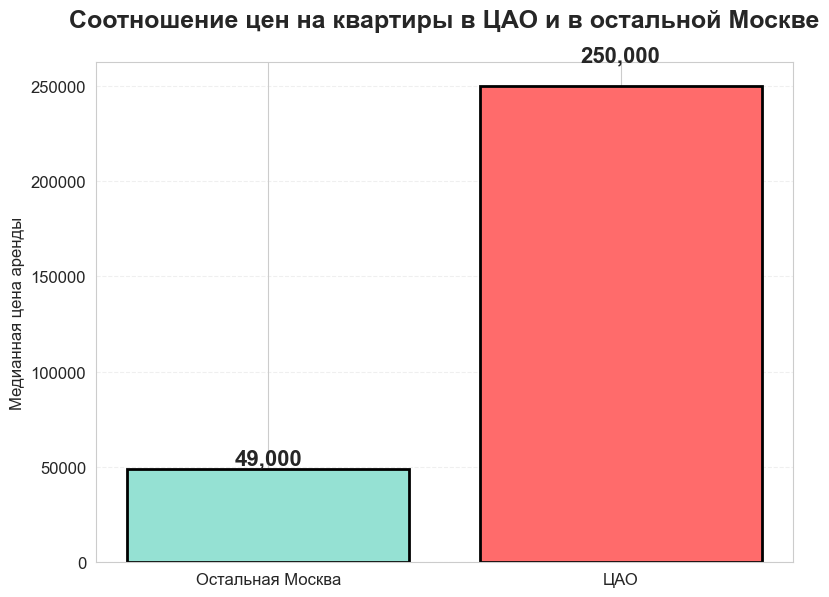

Доля квартир в ЦАО:         0.4%
Доля выручки от ЦАО:        1.4%
Перекос: ЦАО даёт в 3.4 раз больше выручки, чем его доля рынка


In [194]:
cao_areas = ['Арбат','Басманный','Замоскворечье','Красносельский','Мещанский','Пресненский','Таганский','Тверской','Хамовники','Якиманка']
df['is_cao'] = df['Адрес'].astype(str).str.contains('|'.join(cao_areas))

m = df.groupby('is_cao')['monthly_rent_rub'].median()
r = m[True]/m[False]

plt.figure(figsize=(9,6.5))
plt.bar(['Остальная Москва','ЦАО'], m, color=['#95E1D3','#FF6B6B'], edgecolor='black', linewidth=2)
plt.title('Соотношение цен на квартиры в ЦАО и в остальной Москве', fontsize=18, weight='bold', pad=25)
plt.ylabel('Медианная цена аренды'); [plt.text(i, v*1.05, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=16) for i,v in enumerate(m)]
plt.grid(alpha=0.3, axis='y', ls='--'); plt.show()

total_revenue = df['monthly_rent_rub'].sum()
cao_revenue_share = df[df['is_cao']]['monthly_rent_rub'].sum() / total_revenue * 100
cao_apartments_share = df['is_cao'].mean() * 100

print(f"Доля квартир в ЦАО:         {cao_apartments_share:.1f}%")
print(f"Доля выручки от ЦАО:        {cao_revenue_share:.1f}%")
print(f"Перекос: ЦАО даёт в {cao_revenue_share/cao_apartments_share:.1f} раз больше выручки, чем его доля рынка")

**Ключевые факты из данных:**

- Медианная цена аренды в ЦАО: **250 000 ₽**  
- Медианная цена по остальной Москве: **49 000 ₽**  
→ **+410%** (в 5.1 раза дороже!)

- Квартир в ЦАО в датасете: всего **0.4%** (≈90–100 объектов)  
- Но они приносят **1.4% всей месячной выручки** рынка  
→ **Перекос ×3.4**: каждый объект в ЦАО генерирует в 3.4 раза больше денег, чем в среднем по рынку

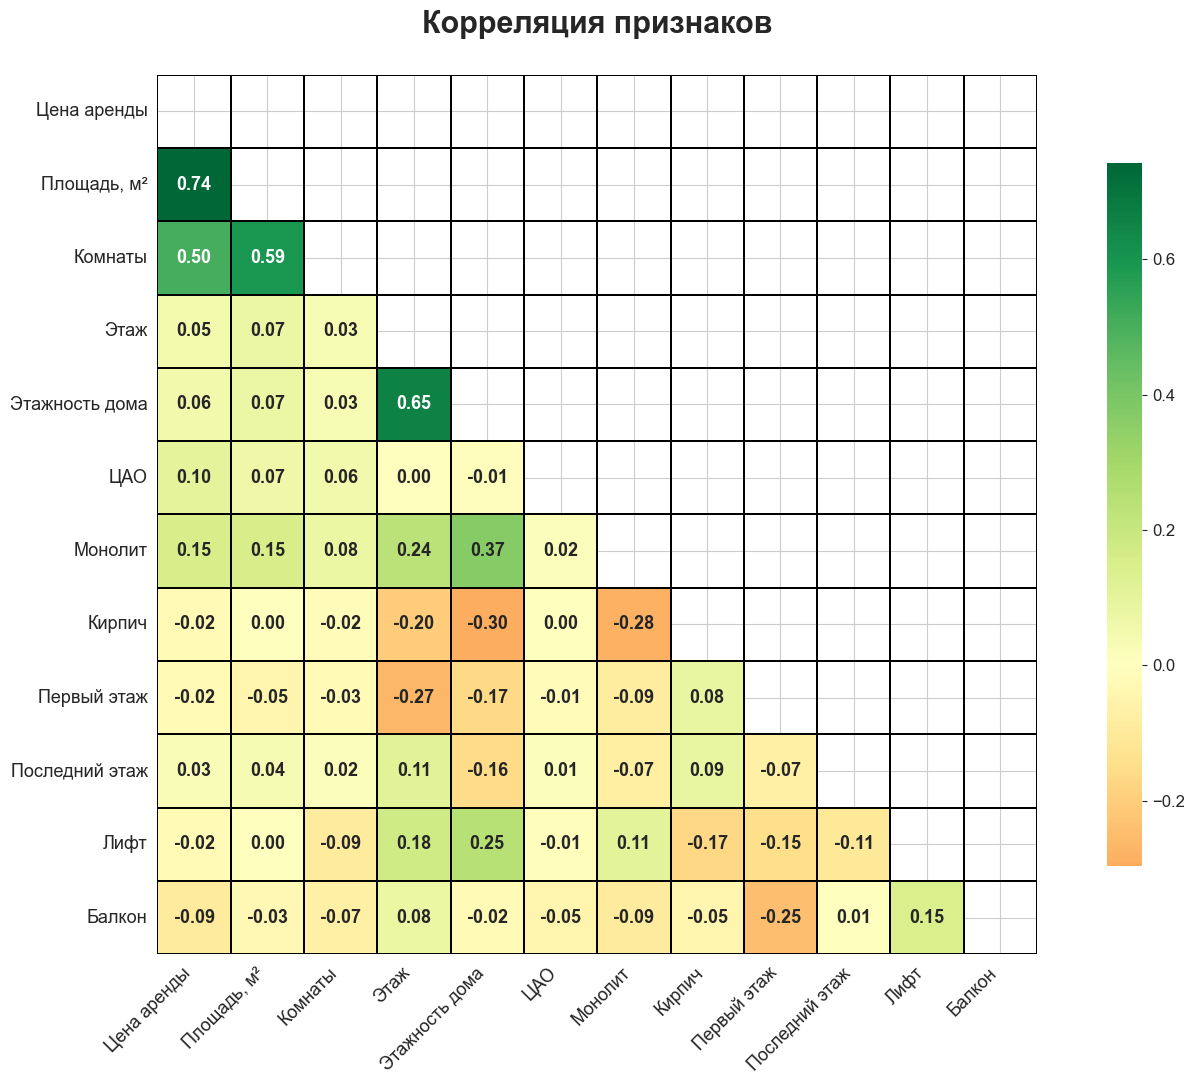

ТОП-10 факторов влияния на цену аренды:
Цена аренды      1.00
Площадь, м²      0.74
Комнаты          0.50
Монолит          0.15
ЦАО              0.10
Балкон           0.09
Этажность дома   0.06
Этаж             0.05
Последний этаж   0.03
Лифт             0.02
Кирпич           0.02
Name: Цена аренды, dtype: float64


In [197]:
# Создание признаков
df['price'] = df['Цена'].str.extract(r'(\d+ ?\d*)').astype(float)
df['floor'], df['total_floors'] = zip(*df['Дом'].str.findall(r'\d+').apply(
    lambda x: [int(x[0]) if x else np.nan, int(x[1]) if len(x)>1 else np.nan]))
df['area'] = df['Площадь, м2'].str.split('/').str[0].str.replace(',','.').astype(float)
df['rooms'] = pd.to_numeric(df['Количество комнат'], errors='coerce').fillna(1)

# Словарь признаков для быстрого создания DataFrame
features = {'Цена аренды': df['price'],
    'Площадь, м²': df['area'],
    'Комнаты': df['rooms'],
    'Этаж': df['floor'],
    'Этажность дома': df['total_floors'],
    'ЦАО': df['Адрес'].str.contains('|'.join(['Арбат','Хамовники','Тверской','Пресненский','Якиманка',
                                              'Замоскворечье','Басманный','Таганский','Мещанский','Красносельский'])),
    'Монолит': df['Дом'].str.contains('Монолит'),
    'Кирпич': df['Дом'].str.contains('Кирпич'),
    'Первый этаж': df['floor'] == 1,
    'Последний этаж': df['floor'] == df['total_floors'],
    'Лифт': df['Лифт'].str.contains('Пасс'),
    'Балкон': df['Балкон'].notna()}

# Создание DataFrame и преобразование в int
f = pd.DataFrame(features).fillna(0).astype(int).dropna(subset=['Цена аренды'])
c = f.corr()

# Визуализация
plt.figure(figsize=(15,11))
sns.heatmap(c, mask=np.triu(np.ones_like(c)), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1.2, linecolor='black', cbar_kws={"shrink":.8}, square=True,
            annot_kws={"size":13, "weight":"bold"})
plt.title('Корреляция признаков', fontsize=22, weight='bold', pad=30)
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout()
plt.show()

print("ТОП-10 факторов влияния на цену аренды:")
print(c['Цена аренды'].abs().sort_values(ascending=False).head(11).round(3))